# Sentence effects: what moves a trace toward its committed distribution

`diagnosis_mentions.py` marks which sentences of a base trace name a diagnosis, and
`tvd_drop.py` measures how much each sentence reduces the trace's remaining disagreement
with where it ends up. This notebook fits the two together: whether the sentence that
first names the eventual diagnosis accounts for more of that reduction than other
sentences, and whether deliberation over rivals continues past the commitment boundary.


In [46]:
import os, sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ValueWarning

# Every fit with trace dummies draws a rank-deficiency note, because only the terms that
# vary within a trace contribute to the clustered covariance and the joint F-test spans
# all of them. The coefficients are checked against an absorbed refit instead, so the
# note carries no information here and forty lines of it per cell hide the output.
warnings.filterwarnings("ignore", category=ValueWarning)

HERE = Path.cwd()
sys.path.insert(0, str(HERE.parents[1] / "src"))
ART = Path(os.environ.get("DCTAX_DATA_ROOT", HERE.parents[1] / "artifacts")) / "rollouts"
OUT = HERE / "out"

from dctax.config import load_resample            # noqa: E402
from dctax.rollouts.utils import trace_summaries  # noqa: E402

experiment = load_resample("screen1000")
MODELS = list(experiment.models)
print(MODELS)

['deepseek-r1-distill-qwen-1.5b', 'deepseek-r1-distill-llama-8b', 'huatuogpt-o1-8b', 'deepseek-r1-distill-qwen-14b', 'gpt-oss-20b', 'glm-4.7-flash', 'gemma-4-31b-it', 'qwq-32b']


In [ ]:
men = pd.read_csv(OUT / "diagnosis_mentions.csv")
# The first sentence of each trace that names its final diagnosis.
first = (men[men["mentions_final"] == 1].groupby("trace_id")["sentence_index"].min()
           .rename("first_mention_index").reset_index())
men = men.merge(first, on="trace_id", how="left")
men["first_mention"] = (men["sentence_index"] == men["first_mention_index"]).astype(int)
# A repeat is a later mention of the same diagnosis.
men["repeat_final"] = ((men["mentions_final"] == 1) & (men["first_mention"] == 0)).astype(int)

print(f"{len(men):,} sentences over {men['trace_id'].nunique()} traces")
print(f"  first_mention  {men['first_mention'].sum():>6,}")
print(f"  repeat_final   {men['repeat_final'].sum():>6,}")
print(f"  mentions_other {men['mentions_other'].sum():>6,}")


In [ ]:
def absorbed(frame, regressors):
    """A within-trace fit of `regressors[0]` on the rest, clustered by trace.

    Absorption costs one degree of freedom per trace that `sm.OLS` cannot see once the
    dummies are gone, so the errors carry the correction Stata's `areg` applies.

    `regressors` is the outcome followed by the terms, so the caller says which
    column is being explained rather than inheriting it from module state.
    """
    outcome, *terms = list(regressors)
    cols = [outcome, *terms]
    w = frame[cols] - frame.groupby("trace_id")[cols].transform("mean")
    m = sm.OLS(w[outcome], w[terms]).fit(
        cov_type="cluster", cov_kwds={"groups": frame["trace_id"]})
    inflate = np.sqrt((len(frame) - len(terms))
                      / (len(frame) - len(terms) - frame["trace_id"].nunique()))
    return m.params, m.bse * inflate


## How much does a sentence move the trace toward where it lands?

`analysis/1_convergence/tvd.py` gives each trace a curve: at boundary $i$, the worst total
variation distance between that boundary's answer distribution and any later boundary's.
It starts high, because the trace still disagrees with where it ends up, and falls to
nothing once the trace has committed. Sentence $i$ sits between boundary $i$ and boundary
$i+1$, so

$$\texttt{tvd\_drop}(i) = \texttt{curve}(i) - \texttt{curve}(i+1)$$

is what writing that sentence did to the disagreement. Positive means it moved the trace
toward its eventual distribution; negative means it reopened the question.


## Why the analysis stops at the commitment boundary

Sentences after the commitment boundary are not comparable to sentences before it, and the
reason is definitional rather than empirical.

Committing at boundary $c$ means every later boundary sits within `BAND` = 0.2 of $c$'s
answer distribution. For any two boundaries $i, j > c$ the triangle inequality gives

$$\mathrm{TVD}(i, j) \le \mathrm{TVD}(i, c) + \mathrm{TVD}(c, j) \le 2 \times \texttt{BAND} = 0.4$$

so the curve cannot exceed 0.4 after commitment, and a drop cannot exceed the value it
falls from. A post-commitment sentence is capped at a drop of 0.4 no matter what it says,
and in practice sits far below that.

Pooling the two sides therefore measures which side of the line a sentence fell on as much
as what it did. That matters here because the sentence kinds are not spread evenly across
the line: 77% of first mentions precede commitment against 30% of repeat mentions, so a
pooled first-versus-repeat contrast is substantially a pre-versus-post contrast wearing a
different label.

**Everything below is restricted to sentences before the commitment boundary**, the window
over which the descent actually happens and where every sentence has the same room to move.

In [59]:
drop = pd.read_csv(OUT / "tvd_drop.csv").merge(
    men[["trace_id", "sentence_index", "mentions_final", "mentions_other",
         "first_mention", "repeat_final"]], on=["trace_id", "sentence_index"])

after = drop[drop["pre_commit"] == 0]
print("what the restriction removes")
print(f"  {len(drop):,} sentences, {len(after):,} after the commitment boundary "
      f"({100 * (1 - drop['pre_commit'].mean()):.1f}%)")
print(f"  their largest curve value is {after['tvd_before'].max():.4f}, "
      f"the 2 x BAND ceiling, attained")
print(f"  their largest drop is {after['tvd_drop'].max():.4f} "
      f"against {drop.loc[drop['pre_commit'] == 1, 'tvd_drop'].max():.4f} before commitment")
print(f"  mean drop {after['tvd_drop'].mean():.4f} after "
      f"against {drop.loc[drop['pre_commit'] == 1, 'tvd_drop'].mean():.4f} before")

print("\nand how unevenly the sentence kinds fall across the line")
for label, mask in (("first mention", drop["first_mention"] == 1),
                    ("repeat of final", drop["repeat_final"] == 1),
                    ("other diagnosis", drop["mentions_other"] == 1)):
    sub = drop[mask]
    print(f"  {label:<16} {100 * sub['pre_commit'].mean():>5.1f}% precede commitment "
          f"({len(sub):,} sentences)")

pre = drop[drop["pre_commit"] == 1].copy()
present_drop = [m for m in MODELS if m in set(pre["model"])]
pre_kind = np.select(
    [pre["first_mention"] == 1, pre["repeat_final"] == 1, pre["mentions_other"] == 1],
    ["first mention", "repeat of final", "other diagnosis"], default="no diagnosis")

print(f"\nanalysis frame: {len(pre):,} sentences over {pre['trace_id'].nunique()} traces")
print(pre.assign(kind=pre_kind).groupby("kind")["tvd_drop"]
         .agg(["size", "mean", "median", "std"]).round(4).to_string())

what the restriction removes
  79,459 sentences, 34,980 after the commitment boundary (44.0%)
  their largest curve value is 0.4000, the 2 x BAND ceiling, attained
  their largest drop is 0.3500 against 1.0000 before commitment
  mean drop 0.0031 after against 0.0142 before

and how unevenly the sentence kinds fall across the line
  first mention     76.9% precede commitment (919 sentences)
  repeat of final   29.5% precede commitment (6,567 sentences)
  other diagnosis   59.7% precede commitment (29,822 sentences)

analysis frame: 44,479 sentences over 1027 traces
                  size    mean  median     std
kind                                          
first mention      707  0.2295  0.1500  0.2783
no diagnosis     24035  0.0063  0.0000  0.1118
other diagnosis  17800  0.0118  0.0000  0.1235
repeat of final   1937  0.0556  0.0316  0.1642


## `tvd_drop ~ first_mention + trace`

Trace is the only covariate. Depth is deliberately left out: more of the descent happens
early, and that is the finding rather than a nuisance, so conditioning on depth would
absorb the thing being measured. What that costs is checked further down, and it turns out
to be nothing.

| spec | `first_mention = 1` against |
| --- | --- |
| 1 | every other pre-commitment sentence |
| 2 | pre-commitment sentences that repeat the final diagnosis |
| 3 | pre-commitment sentences naming some other diagnosis |

In [60]:
DROP_FORMULA = "tvd_drop ~ first_mention + C(trace_id)"

SETS = {
    "1. vs every other sentence": lambda f: f,
    "2. vs repeats of the final diagnosis":
        lambda f: f[(f["first_mention"] == 1) | (f["repeat_final"] == 1)],
    "3. vs sentences naming another diagnosis":
        lambda f: f[(f["first_mention"] == 1) | (f["mentions_other"] == 1)],
}

for label, select in SETS.items():
    frame = select(pre)
    m = smf.ols(DROP_FORMULA, data=frame).fit(
        cov_type="cluster", cov_kwds={"groups": frame["trace_id"]})
    # Only one regressor varies within a trace, so the clustered covariance has rank 1;
    # the absorbed refit is the check that the pseudo-inverse landed on it.
    params, bse = absorbed(frame, ["tvd_drop", "first_mention"])
    print(f"--- {label}")
    print(f"    n={int(m.nobs):,}  traces={frame['trace_id'].nunique()}  "
          f"first_mention rows={int(frame['first_mention'].sum()):,}  R2={m.rsquared:.4f}")
    print(m.summary2().tables[1].loc[["first_mention"]].round(4).to_string())
    print(f"    absorbed check: coef={params['first_mention']:.4f}  "
          f"se={bse['first_mention']:.4f}\n")

--- 1. vs every other sentence
    n=44,479  traces=1027  first_mention rows=707  R2=0.0607
                Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
first_mention  0.2096    0.0107  19.6557    0.0  0.1887  0.2305
    absorbed check: coef=0.2096  se=0.0107

--- 2. vs repeats of the final diagnosis
    n=2,644  traces=707  first_mention rows=707  R2=0.6234
                Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
first_mention -0.0007    0.0126 -0.0586  0.9533 -0.0255   0.024
    absorbed check: coef=-0.0007  se=0.0126

--- 3. vs sentences naming another diagnosis
    n=18,507  traces=1008  first_mention rows=707  R2=0.1598
                Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
first_mention  0.2058    0.0109  18.9548    0.0  0.1846  0.2271
    absorbed check: coef=0.2058  se=0.0109



### Spec 2 is null, and that is the result rather than a failure

Specs 1 and 3 are large. Spec 2, the contrast against repeat mentions, is zero.

Pooled over the whole trace it was +0.121, which is what the restriction has removed: most
repeats land after commitment, where a drop is capped at 0.4 and averages 0.006, so the
pooled contrast was largely comparing across the commitment line. Inside the open window the
two are indistinguishable.

The regression is a within-trace estimator, so only traces holding both a first mention and
a pre-commitment repeat identify it. Pairing those traces directly says the same thing in a
form that is harder to misread.

In [61]:
from scipy import stats  # noqa: E402, F811

two = pre[(pre["first_mention"] == 1) | (pre["repeat_final"] == 1)]
paired = np.array([
    [g.loc[g["first_mention"] == 1, "tvd_drop"].iloc[0],
     g.loc[g["repeat_final"] == 1, "tvd_drop"].mean()]
    for _, g in two.groupby("trace_id")
    if g["first_mention"].sum() == 1 and g["repeat_final"].sum() >= 1])
diff = paired[:, 0] - paired[:, 1]

print(f"{len(paired)} traces hold both kinds before the commitment boundary")
print(f"  the first mention              {paired[:, 0].mean():.4f}")
print(f"  that trace's own later repeats {paired[:, 1].mean():.4f}")
print(f"  paired difference              {diff.mean():+.4f}")
print(f"  paired t p = {stats.ttest_1samp(diff, 0).pvalue:.3g}, "
      f"Wilcoxon p = {stats.wilcoxon(diff).pvalue:.3g}")
print(f"  first mention is the larger drop in {100 * (diff > 0).mean():.1f}% of them")

400 traces hold both kinds before the commitment boundary
  the first mention              0.1126
  that trace's own later repeats 0.1165
  paired difference              -0.0039
  paired t p = 0.75, Wilcoxon p = 0.723
  first mention is the larger drop in 47.5% of them


So the finding is about **naming the diagnosis while the trace is still open**, not about
the first naming specifically. Within the open window a first mention and a repeat move the
curve by the same amount. What makes the first mention look special in an unrestricted
analysis is that it is far more likely to fall inside that window at all.

### Per model

Model does not vary within a trace, so as before the only way to let the effect differ by
model is to fit it by model.

In [62]:
rows = []
for label, select in SETS.items():
    for name, g in select(pre).groupby("model"):
        if g["first_mention"].sum() < 5 or g["first_mention"].nunique() < 2:
            continue
        m = smf.ols(DROP_FORMULA, data=g).fit(
            cov_type="cluster", cov_kwds={"groups": g["trace_id"]})
        t = m.summary2().tables[1].loc["first_mention"]
        rows.append({"spec": label.split(".")[0], "model": name, "n": int(m.nobs),
                     "n_fm": int(g["first_mention"].sum()),
                     "coef": t["Coef."], "se": t["Std.Err."], "p": t["P>|z|"]})
by_model = pd.DataFrame(rows)
print(by_model.pivot(index="model", columns="spec", values=["coef", "se", "p"])
        .reindex(present_drop).round(4).to_string())
print("\nfirst-mention rows per model and spec")
print(by_model.pivot(index="model", columns="spec", values="n_fm")
        .reindex(present_drop).to_string())

                                 coef                      se                       p                
spec                                1       2       3       1       2       3       1       2       3
model                                                                                                
deepseek-r1-distill-qwen-1.5b  0.4297 -0.0004  0.4584  0.0396  0.0807  0.0408  0.0000  0.9964  0.0000
deepseek-r1-distill-llama-8b   0.3029 -0.0326  0.3014  0.0296  0.0497  0.0312  0.0000  0.5119  0.0000
huatuogpt-o1-8b                0.2350  0.0032  0.2308  0.0408  0.0999  0.0475  0.0000  0.9746  0.0000
deepseek-r1-distill-qwen-14b   0.2054 -0.0237  0.2043  0.0240  0.0407  0.0242  0.0000  0.5598  0.0000
gpt-oss-20b                    0.1049  0.0143  0.1050  0.0220  0.0270  0.0224  0.0000  0.5963  0.0000
glm-4.7-flash                  0.1675  0.0376  0.1603  0.0187  0.0205  0.0182  0.0000  0.0671  0.0000
gemma-4-31b-it                 0.0591 -0.0449  0.0550  0.0247  0.0330  0.0250  0.0

### The per-model coefficients are not comparable as they stand

$\Delta\rho_i$ is a drop *per sentence*, and the models differ enormously in how many
sentences they write, so a coefficient in raw units mixes the size of the effect with the
length of the trace. Dividing by each model's own mean per-sentence drop gives a comparable
quantity: how many average sentences' worth of descent a first mention delivers.

In [ ]:
rows = []
for name, g in pre.groupby("model"):
    m = smf.ols(DROP_FORMULA, data=g).fit(
        cov_type="cluster", cov_kwds={"groups": g["trace_id"]})
    rows.append({"model": name,
                 "median_sentences": g.groupby("trace_id").size().median(),
                 "coef": m.params["first_mention"],
                 "mean_drop": g["tvd_drop"].mean(),
                 "in_sentence_units": m.params["first_mention"] / g["tvd_drop"].mean()})
units = pd.DataFrame(rows).set_index("model").reindex(present_drop)
print(units.round(4).to_string())

raw_rho, raw_p = stats.spearmanr(units["median_sentences"], units["coef"])
adj_rho, adj_p = stats.spearmanr(units["median_sentences"], units["in_sentence_units"])
print(f"\nSpearman(median sentences, raw coefficient)      {raw_rho:+.3f}  p = {raw_p:.3g}")
print(f"Spearman(median sentences, length-normalised)    {adj_rho:+.3f}  p = {adj_p:.3g}")
print(f"spread: raw {units['coef'].max() / units['coef'].min():.1f}x, "
      f"normalised {units['in_sentence_units'].max() / units['in_sentence_units'].min():.1f}x")

The raw ordering is almost entirely trace length, and normalising inverts it: GLM has the
smallest raw coefficient of the larger models and the largest in sentence units, because it
writes about 140 sentences per trace against the 1.5b's 16. Do not read the raw column as a
model-scale effect, and do not order a figure by it without saying so.

### What depth would do to it

Not the specified model. This is here to show how much of the `first_mention` coefficient is
shared with depth, since models differ a lot in when they name their diagnosis and drops are
larger early. Unlike the counterfactual outcome, where depth reversed Gemma's sign, a drop
is already a difference and the positional trend in the level differences out.

In [63]:
rows = []
for label, select in SETS.items():
    frame = select(pre)
    row = {"spec": label.split(".")[0]}
    for variant, formula in (
            ("as specified", DROP_FORMULA),
            ("+ depth", "tvd_drop ~ first_mention + token_position + C(trace_id)")):
        m = smf.ols(formula, data=frame).fit(
            cov_type="cluster", cov_kwds={"groups": frame["trace_id"]})
        t = m.summary2().tables[1].loc["first_mention"]
        row[variant] = f"{t['Coef.']:.4f} ({t['Std.Err.']:.4f})"
    rows.append(row)
print(pd.DataFrame(rows).set_index("spec").to_string())

          as specified          + depth
spec                                   
1      0.2096 (0.0107)  0.2059 (0.0104)
2     -0.0007 (0.0126)  0.0293 (0.0137)
3      0.2058 (0.0109)  0.2028 (0.0105)


### Any mention rather than the first

`first_mention` depends on the sentence splitter identifying which mention came first,
which is fragile: GLM names its diagnosis inside a bulleted heading, so the sentence that
actually moves the curve is often tagged a repeat. Repeating the fit with an indicator for
*any* mention of the final diagnosis needs no such judgement.

In [ ]:
from scipy.stats import norm  # noqa: E402

rows = []
for term, frame, label in (
        ("first_mention", pre, "vs all other sentences"),
        ("mentions_final", pre, "vs all other sentences"),
        ("first_mention", pre[(pre["first_mention"] == 1) | (pre["mentions_other"] == 1)],
         "vs sentences naming a rival"),
        ("mentions_final", pre[(pre["mentions_final"] == 1) | (pre["mentions_other"] == 1)],
         "vs sentences naming a rival")):
    m = smf.ols(f"tvd_drop ~ {term} + C(trace_id)", data=frame).fit(
        cov_type="cluster", cov_kwds={"groups": frame["trace_id"]})
    b, se = m.params[term], m.bse[term]
    rows.append({"regressor": term, "comparison": label, "n": len(frame),
                 "treated": int(frame[term].sum()), "coef": b, "se": se,
                 "z": b / se, "p": 2 * norm.sf(abs(b / se))})
print(pd.DataFrame(rows).set_index(["regressor", "comparison"]).round(4).to_string())

The estimate halves. That looks like attenuation and is not: within a trace, a first
mention and a later one are indistinguishable (the null above), so pooling them cannot
weaken a real per-sentence effect. What it does is average two kinds of trace together.

In [ ]:
has_repeat = set(pre.loc[pre["repeat_final"] == 1, "trace_id"])
fm = pre[pre["first_mention"] == 1]
solo, multi = fm[~fm["trace_id"].isin(has_repeat)], fm[fm["trace_id"].isin(has_repeat)]

print(f"names the answer once before committing:      {len(solo):>4} traces, "
      f"first-mention drop {solo['tvd_drop'].mean():.4f}")
print(f"names it more than once before committing:    {len(multi):>4} traces, "
      f"first-mention drop {multi['tvd_drop'].mean():.4f}")
print(f"                                                   their repeats      "
      f"{pre.loc[pre['repeat_final'] == 1, 'tvd_drop'].mean():.4f}")

# The quantity that is actually invariant: the whole budget of commitment a trace spends
# on naming its answer, however many sentences it takes to spend it.
total = pre[pre["mentions_final"] == 1].groupby("trace_id")["tvd_drop"].agg(["sum", "size"])
total["kind"] = np.where(total.index.isin(has_repeat), "names it repeatedly",
                         "names it once")
print("\ntotal drop delivered by all answer-naming sentences of a trace")
print(total.groupby("kind").agg(traces=("sum", "size"), mean_total=("sum", "mean"),
                                mean_mentions=("size", "mean")).round(4).to_string())

The totals match to four decimal places. A trace that names its answer once puts the whole
budget on that sentence; a trace that names it six times spreads the same budget across
them. So the halving is partitioning, not attenuation, and the invariant quantity is the
per-trace total rather than either per-sentence coefficient.

## Plots

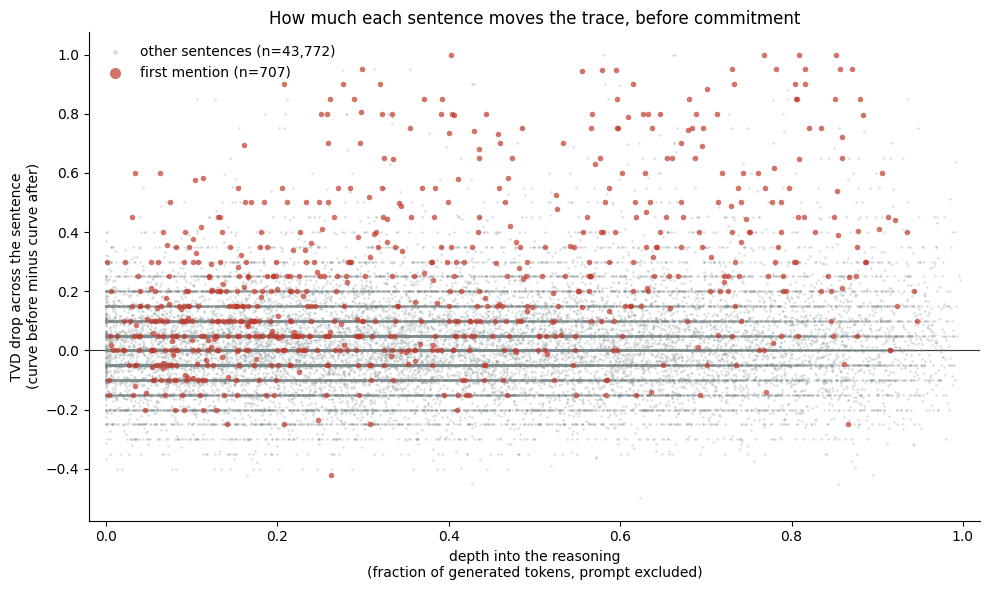

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))
rest = pre[pre["first_mention"] == 0]
hit = pre[pre["first_mention"] == 1]
ax.axhline(0, color="#333333", linewidth=0.8, zorder=1)
ax.scatter(rest["token_position"], rest["tvd_drop"], s=3, alpha=0.3,
           color="#7f8c8d", linewidths=0, label=f"other sentences (n={len(rest):,})")
ax.scatter(hit["token_position"], hit["tvd_drop"], s=16, alpha=0.7,
           color="#c0392b", linewidths=0, label=f"first mention (n={len(hit):,})")
ax.set_xlabel("depth into the reasoning\n(fraction of generated tokens, prompt excluded)")
ax.set_ylabel("TVD drop across the sentence\n(curve before minus curve after)")
ax.set_title("How much each sentence moves the trace, before commitment", fontsize=12)
ax.set_xlim(-0.02, 1.02)
ax.legend(frameon=False, markerscale=2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "tvd_drop_vs_position_scatter.png", dpi=180)

In [ ]:
from statsmodels.stats.multitest import multipletests  # noqa: E402

def stars(p):
    """Conventional marks, with `ns` rather than a blank so absence is visible."""
    for cut, mark in ((0.001, "***"), (0.01, "**"), (0.05, "*")):
        if p < cut:
            return mark
    return "ns"

# The brackets carry the per-model within-trace coefficient, not a test on the two plotted
# distributions: the boxes are marginal, the fit is within trace. That pairing is only
# honest while the two agree, so it is checked rather than assumed.
marks = {}
check = []
for name in present_drop:
    g = pre[pre["model"] == name]
    m = smf.ols(DROP_FORMULA, data=g).fit(
        cov_type="cluster", cov_kwds={"groups": g["trace_id"]})
    t = m.summary2().tables[1].loc["first_mention"]
    hit = g.loc[g["first_mention"] == 1, "tvd_drop"]
    rest = g.loc[g["first_mention"] == 0, "tvd_drop"]
    check.append({"model": name, "coef": t["Coef."], "p_within": t["P>|z|"],
                  "raw_diff": hit.mean() - rest.mean(),
                  "p_marginal": stats.mannwhitneyu(hit, rest).pvalue})
check = pd.DataFrame(check).set_index("model")
for source in ("within", "marginal"):
    check[f"q_{source}"] = multipletests(check[f"p_{source}"], method="fdr_bh")[1]
agree = ((np.sign(check["coef"]) == np.sign(check["raw_diff"]))
         & ((check["q_within"] < 0.05) == (check["q_marginal"] < 0.05)))
print(check.round(4).to_string())
print(f"\nadjusted and unadjusted agree in {int(agree.sum())} of {len(agree)} models"
      + ("" if agree.all() else f": {', '.join(agree[~agree].index)} differ"))
marks = {m: stars(q) for m, q in check["q_within"].items()}
check.round(6).to_csv(OUT / "tvd_drop_model_tests.csv")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.axhline(0, color="#333333", linewidth=0.8, zorder=1)

tops = np.full(len(present_drop), -np.inf)
for offset, flag, colour, label in ((-0.18, 0, "#95a5a6", "other sentences"),
                                    (0.18, 1, "#c0392b", "first mention")):
    data = [pre.loc[(pre["model"] == m) & (pre["first_mention"] == flag), "tvd_drop"]
            for m in present_drop]
    drawn = ax.boxplot(data, positions=[i + offset for i in range(len(present_drop))],
                       widths=0.32, patch_artist=True, showfliers=False,
                       medianprops={"color": "#111111", "linewidth": 1.5})
    for box in drawn["boxes"]:
        box.set_facecolor(colour)
        box.set_alpha(0.85)
        box.set_edgecolor("#444444")
    drawn["boxes"][0].set_label(label)
    # Whiskers are the visible extent once fliers are hidden, so brackets clear those.
    for i in range(len(present_drop)):
        for whisker in drawn["whiskers"][2 * i:2 * i + 2]:
            tops[i] = max(tops[i], whisker.get_ydata().max())

span = tops.max() - min(0.0, pre["tvd_drop"].min())
gap, tick = 0.045 * span, 0.018 * span
for i, name in enumerate(present_drop):
    y = tops[i] + gap
    ax.plot([i - 0.18, i - 0.18, i + 0.18, i + 0.18],
            [y, y + tick, y + tick, y], color="#333333", linewidth=1.1)
    ax.text(i, y + tick * 1.15, marks[name], ha="center", va="bottom",
            fontsize=11 if marks[name] != "ns" else 9, color="#333333")

ax.set_xticks(range(len(present_drop)))
ax.set_xticklabels([m.replace("deepseek-r1-distill-", "ds-") for m in present_drop],
                   rotation=30, ha="right")
ax.set_ylabel(r"$\Delta\rho_i$", fontsize=15)
ax.set_title("TVD drop at the first mention of the final diagnosis, "
             "pre-commitment sentences only", fontsize=12)
ax.set_ylim(top=(tops + gap).max() + tick * 6)
ax.legend(frameon=False, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.01, 0.01,
         "brackets: tvd_drop ~ first_mention + C(trace_id), clustered by trace, "
         "BH corrected over models.   *** q<0.001  ** q<0.01  * q<0.05",
         fontsize=8, color="#666666")
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(OUT / "tvd_drop_by_model_boxplot.png", dpi=180)

## The 300 largest drops, for reading

Ranked over the pre-commitment sentences. `kind` says whether the sentence names the trace's
final diagnosis for the first time, repeats it, names a rival, or names none. The full table
goes to `out/top_drops.csv` with the sentence text untruncated.

In [66]:
TOP = 300

text = {(t.trace_id, i): s
        for m in MODELS for t in trace_summaries(experiment.sweep_run(m))
        for i, s in enumerate(t.sentences)}

top = pre.nlargest(TOP, "tvd_drop").copy()
top["kind"] = np.select(
    [top["first_mention"] == 1, top["repeat_final"] == 1, top["mentions_other"] == 1],
    ["first", "repeat", "other"], default="none")
top["sentence"] = [text.get((r.trace_id, r.sentence_index), "") for r in top.itertuples()]
top["rank"] = range(1, len(top) + 1)

cols = ["rank", "model", "trace_id", "sentence_index", "token_position",
        "tvd_before", "tvd_after", "tvd_drop", "kind", "sentence"]
top[cols].to_csv(OUT / "top_drops.csv", index=False)

print(f"composition of the top {TOP}")
print(top["kind"].value_counts().to_string())
print(f"\nby model\n{top['model'].value_counts().to_string()}")
print(f"\nmedian depth {top['token_position'].median():.3f}, "
      f"drop range {top['tvd_drop'].min():.3f} to {top['tvd_drop'].max():.3f}\n")

with pd.option_context("display.max_rows", None, "display.width", 250,
                       "display.max_colwidth", 110):
    print(top[["rank", "model", "token_position", "tvd_drop", "kind", "sentence"]]
          .assign(model=lambda f: f["model"].str.replace("deepseek-r1-distill-", "ds-"),
                  sentence=lambda f: f["sentence"].str.replace(r"\s+", " ", regex=True))
          .round(3).to_string(index=False))

composition of the top 300
kind
first     133
other      87
repeat     50
none       30

by model
model
deepseek-r1-distill-qwen-1.5b    84
deepseek-r1-distill-llama-8b     64
deepseek-r1-distill-qwen-14b     47
glm-4.7-flash                    30
qwq-32b                          27
huatuogpt-o1-8b                  22
gpt-oss-20b                      18
gemma-4-31b-it                    8

median depth 0.577, drop range 0.467 to 1.000

 rank           model  token_position  tvd_drop   kind                                                                                                                                                                                                                                                                                                                                                                                                                               sentence
    1    ds-qwen-1.5b           0.808     1.000  first                            

# Does commitment end the deliberation?

The analysis above stops at the commitment boundary because a drop is capped there. The
text after it is still worth measuring, just not with $\Delta\rho_i$: the question is
whether the trace stops entertaining diagnoses it will not choose.

One rate per trace, so a 224-sentence Gemma trace does not outweigh a 16-sentence one, and
the two rates are paired within a trace. A trace needs both windows to contribute, which
excludes those committing at $i_0$ and those that never commit, and at least a few
sentences on each side, since a rate over two sentences is 0, 0.5 or 1.

In [ ]:
MIN_WINDOW = 5

commit = drop[["trace_id", "commit_boundary"]].drop_duplicates("trace_id")
rival = men.merge(commit, on="trace_id", how="inner")
rival["post"] = (rival["sentence_index"] >= rival["commit_boundary"]).astype(int)

wide = (rival.groupby(["model", "trace_id", "post"])["mentions_other"]
             .agg(["mean", "size"]).unstack("post"))
wide.columns = ["pre_rate", "post_rate", "n_pre", "n_post"]
wide = wide.dropna().reset_index()
rates = wide[(wide["n_pre"] >= MIN_WINDOW) & (wide["n_post"] >= MIN_WINDOW)]
print(f"{len(wide)} traces with both windows; {len(rates)} keep at least "
      f"{MIN_WINDOW} sentences on each side")

diff = rates["post_rate"] - rates["pre_rate"]
print(f"\npooled: median {rates['pre_rate'].median():.3f} before, "
      f"{rates['post_rate'].median():.3f} after")
print(f"  within-trace change {diff.median():+.3f}, "
      f"Wilcoxon signed-rank p = {stats.wilcoxon(diff).pvalue:.2e}")
print(f"  the rate falls at all in {100 * (diff < 0).mean():.1f}% of traces")

In [ ]:
rows = []
for name in [m for m in MODELS if m in set(rates["model"])]:
    g = rates[rates["model"] == name]
    d = g["post_rate"] - g["pre_rate"]
    rows.append({"model": name, "traces": len(g),
                 "pre_median": g["pre_rate"].median(),
                 "post_median": g["post_rate"].median(),
                 "delta_median": d.median(),
                 "p": stats.wilcoxon(d).pvalue})
rival_tests = pd.DataFrame(rows).set_index("model")
rival_tests["q"] = multipletests(rival_tests["p"], method="fdr_bh")[1]
print(rival_tests.round(4).to_string())
print(f"\nsignificant reduction in {int((rival_tests['q'] < 0.05).sum())} "
      f"of {len(rival_tests)} models")
rival_tests.round(6).to_csv(OUT / "rival_rate_tests.csv")

In [ ]:
order = [m for m in MODELS if m in set(rates["model"])]
fig, ax = plt.subplots(figsize=(12, 6.5))

tops = np.full(len(order), -np.inf)
for offset, column, colour, label in ((-0.18, "pre_rate", "#3c6e9f", "before commitment"),
                                      (0.18, "post_rate", "#d98b3a", "after commitment")):
    data = [rates.loc[rates["model"] == m, column] for m in order]
    drawn = ax.boxplot(data, positions=[i + offset for i in range(len(order))],
                       widths=0.32, patch_artist=True, showfliers=False,
                       medianprops={"color": "#111111", "linewidth": 1.5})
    for box in drawn["boxes"]:
        box.set_facecolor(colour)
        box.set_alpha(0.85)
        box.set_edgecolor("#444444")
    drawn["boxes"][0].set_label(label)
    for i in range(len(order)):
        for whisker in drawn["whiskers"][2 * i:2 * i + 2]:
            tops[i] = max(tops[i], whisker.get_ydata().max())

gap, tick = 0.05, 0.018
for i, name in enumerate(order):
    y = tops[i] + gap
    ax.plot([i - 0.18, i - 0.18, i + 0.18, i + 0.18],
            [y, y + tick, y + tick, y], color="#333333", linewidth=1.1)
    mark = stars(rival_tests.loc[name, "q"])
    ax.text(i, y + tick * 1.15, mark, ha="center", va="bottom",
            fontsize=11 if mark != "ns" else 9, color="#333333")

ax.set_xticks(range(len(order)))
ax.set_xticklabels([m.replace("deepseek-r1-distill-", "ds-") for m in order],
                   rotation=30, ha="right")
ax.set_ylabel("proportion of sentences naming a rival diagnosis")
ax.set_title("Rival-diagnosis mentions before and after commitment, per trace", fontsize=12)
ax.set_ylim(0, (tops + gap).max() + tick * 6)
ax.legend(frameon=False, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.01, 0.01,
         "one rate per trace; brackets: Wilcoxon signed-rank on the within-trace "
         "difference, BH corrected over models.   *** q<0.001  ** q<0.01  * q<0.05",
         fontsize=8, color="#666666")
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(OUT / "rival_rate_by_model_boxplot.png", dpi=180)
rates.to_csv(OUT / "rival_rate_per_trace.csv", index=False)

The rate falls, but barely, and in only slightly more than half of traces. Models go on
naming diagnoses they will not choose at close to the pre-commitment rate long after the
answer distribution has stopped moving, which is the deliberation-outlasts-commitment
claim stated on the text rather than on the distribution.

One limitation to carry: `mentions_other` is a lexical match against the case's other
judged answers, so a sentence dismissing a differential counts the same as one seriously
weighing it. This measures rival-diagnosis **mention**, not rival-diagnosis
**consideration**.

## Notes

- **`first_mention` is at most one sentence per trace**, so a trace contributes the term
  once or not at all.
- **Traces with no mention of their own final diagnosis** drop out of the contrasts that
  require one.
- **A sentence naming both the final diagnosis and another is counted as final**, so
  `mentions_other` is the set naming a rival and not the eventual answer.
- **`first_mention` depends on the sentence splitter** identifying which mention comes
  first; a mention split across two sentences would move it.
